# Heart Disease Risk Prediction using Logistic Regression

## Nicolás Toro Criollo

---

### Introducción

BLA BLA BLA [Cambiarlo]

### 1. Imports

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 2. Dataset

In [53]:
df = pd.read_csv('heart.csv')

df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### 3. Exploratory Data Analysis

We initialy are going to explore the dataset to understand the features and their relationships with the target variable. This will help us identify any patterns or trends that may be useful for our logistic regression model.

**Key Variable Distribution**

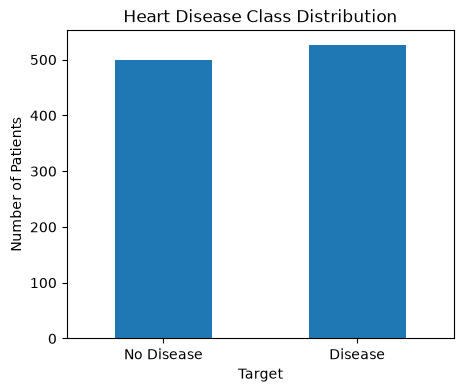

In [54]:
df["target"].value_counts()

plt.figure(figsize=(5,4))
df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks([0,1], ["No Disease","Disease"], rotation=0)

plt.show()

**Outliers Detection** 

C:\Users\nikot\AppData\Local\Temp\ipykernel_1328\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=True)
C:\Users\nikot\AppData\Local\Temp\ipykernel_1328\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=True)
C:\Users\nikot\AppData\Local\Temp\ipykernel_1328\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[feature], vert=True)
C:\Users\nikot\AppData\Local\Temp\ipykernel_1328\2507574595.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} ins

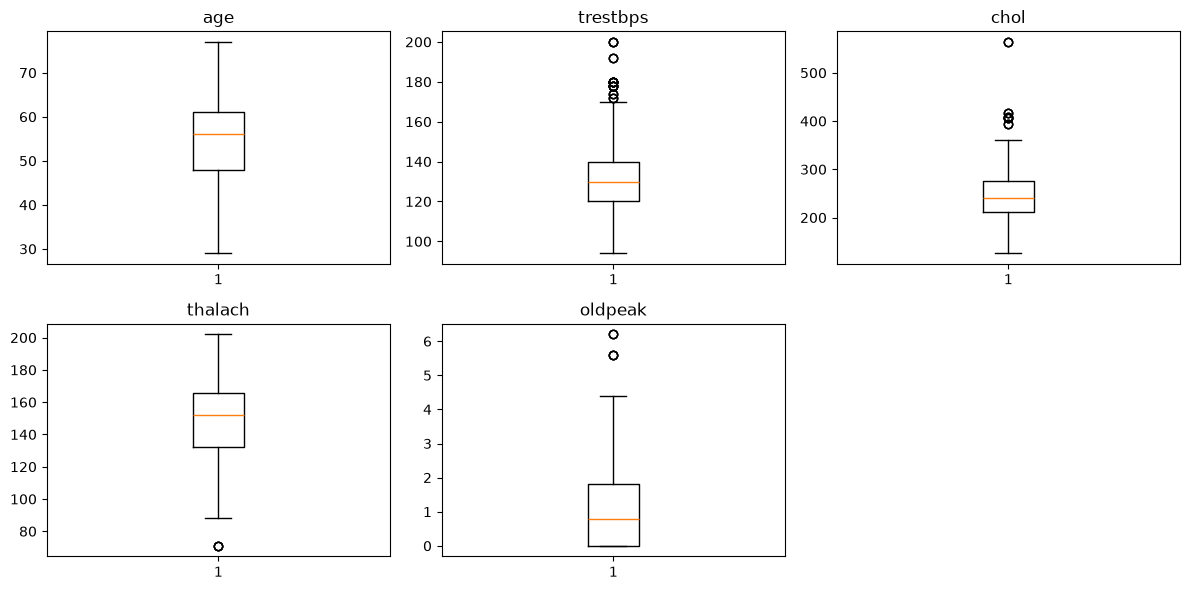

In [55]:
features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(12,6))

for i, feature in enumerate(features):
    plt.subplot(2,3,i+1)
    plt.boxplot(df[feature], vert=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

**Outlier Analysis**
 
Boxplots were generated for the main numerical variables.

Several potential outliers were identified in resting blood pressure, cholesterol, and ST depression (oldpeak). Since this dataset contains real clinical measurements, these values are considered medically plausible rather than data entry errors.

Therefore, no observations were removed. Instead, feature normalization will be applied before training the Logistic Regression model.

**Target variable verification**

In [56]:
df["target"].unique()

array([0, 1])

Due to the nature of the dataset, the target variable is binary, so its inncesary to do steps like one-hot encoding or label encoding. The target variable is already in a suitable format for logistic regression.

**Class distribution**

It's important to do a class distribution analysis to understand the balance of the target variable. This will help us determine if any techniques, such as oversampling or undersampling, are needed to address class imbalance before training the model.

Class Distribution:
target
0    499
1    526
Name: count, dtype: int64
Class Distribution (Percentage):
target
0    48.68
1    51.32
Name: count, dtype: float64


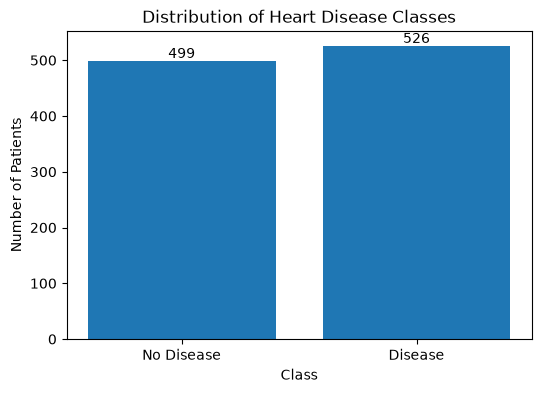

In [57]:
class_distribution = df["target"].value_counts().sort_index()

print("Class Distribution:" )
print(class_distribution) 

print("Class Distribution (Percentage):" )
print((class_distribution / len(df) * 100).round(2))

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["No Disease", "Disease"],
    class_distribution.values
)

plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

# Mostrar valores encima de cada barra
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center'
    )

plt.show()

The target variable was inspected to verify its encoding before model training.

The dataset already provides a binary target variable:

- **0:** No heart disease
- **1:** Presence of heart disease

Therefore, no additional binarization was required.

The class distribution shows:

| Class | Patients | Percentage |
|------|---------:|-----------:|
| No Disease | 499 | 48.68% |
| Disease | 526 | 51.32% |

The dataset is well balanced, with only a small difference between both classes. Consequently, no resampling techniques were required, and a stratified train-test split will be used to preserve this distribution in both subsets.


### 4. Data Preprocesing

According to intructions, sex clinical variable were selected for training the model. The rest of the features were discarded:

- Age (`age`)
- Resting blood pressure (`trestbps`)
- Serum cholesterol (`chol`)
- Maximum heart rate achieved (`thalach`)
- ST depression induced by exercise (`oldpeak`)
- Number of major vessels colored by fluoroscopy (`ca`)

These variables are impotant for the model providing relevant information about the patient's health status and risk factors for heart disease.

In [58]:
selected_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

X = df[selected_features]
y = df["target"]

print("Selected Features:")
print(X.head())

Selected Features:
   age  trestbps  chol  thalach  oldpeak  ca
0   52       125   212      168      1.0   2
1   53       140   203      155      3.1   0
2   70       145   174      125      2.6   0
3   61       148   203      161      0.0   1
4   62       138   294      106      1.9   3


**Train/Test Split**

The dataset was first separated by class, each subset was randomly shuffled, and a 70/30 partition was applied independently. Finally, both classes were merged and shuffled again to produce the final training and testing datasets.

This approach preserves the original class distribution while avoiding the use of external data splitting utilities.

In [59]:
# Separar registros por clase
class_0 = df[df["target"] == 0]
class_1 = df[df["target"] == 1]

# Mezclar los registros de cada clase para evitar sesgos
np.random.seed(42)

class_0 = class_0.sample(frac=1, random_state=42).reset_index(drop=True)
class_1 = class_1.sample(frac=1, random_state=42).reset_index(drop=True)

# Calcular el tamaño del entrenamiento
train_size_0 = int(0.7 * int(len(class_0)))
train_size_1 = int(0.7 * int(len(class_1)))

# Dividir en conjuntos de entrenamiento y prueba
train_0 = class_0.iloc[:train_size_0]
test_0 = class_0.iloc[train_size_0:]

train_1 = class_1.iloc[:train_size_1]
test_1 = class_1.iloc[train_size_1:]

# Unir los conjuntos de entrenamiento y prueba
train_df = pd.concat([train_0, train_1])
test_df = pd.concat([test_0, test_1])

# Mezclar los conjuntos de entrenamiento y prueba
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separar variables y etiquetas
X_train = train_df[selected_features]
y_train = train_df["target"]

X_test = test_df[selected_features]
y_test = test_df["target"]

# Verificación
print("Training set:", len(train_df))
print("Test set:", len(test_df))

print("\nTraining distribution")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting distribution")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set: 717
Test set: 308

Training distribution
target
1    51.32
0    48.68
Name: proportion, dtype: float64

Testing distribution
target
1    51.3
0    48.7
Name: proportion, dtype: float64


**Normalization**

It's important to normalize the features before training the logistic regression model because they have different scales and units. Normalization ensures that all features contribute equally to the model's learning process, preventing any single feature from dominating the others due to its scale.

In [60]:
# Calcular la media del entrenamiento
train_mean = np.mean(X_train, axis=0)

# Calcular la desviación estándar del entrenamiento
train_std = np.std(X_train, axis=0)

# Evitar división por cero
train_std = np.where(train_std == 0, 1, train_std)

# Normalizar los datos de entrenamiento
X_train_norm = (X_train - train_mean) / train_std

# Normalizar los datos de prueba
X_test_norm = (X_test - train_mean) / train_std

# Verificación de la normalización
print("Training Mean:")
print(np.round(np.mean(X_train_norm, axis=0), 5))

print("\nTraining Standard Deviation:")
print(np.round(np.std(X_train_norm, axis=0), 5))

Training Mean:
age         0.0
trestbps    0.0
chol        0.0
thalach    -0.0
oldpeak    -0.0
ca          0.0
dtype: float64

Training Standard Deviation:
age         1.0
trestbps    1.0
chol        1.0
thalach     1.0
oldpeak     1.0
ca          1.0
dtype: float64


### 5. Logistic Regression Implementation

Before training the Logisic Model, we need the dataset in the correct format. Thats why we will convert the DataFrames from Pandas to Numpy arrays. This will allow us to perform matrix operations more efficiently during the training process. 

In [61]:
X_train = X_train_norm.to_numpy()
X_test = X_test_norm.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)

print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train:  (717, 6)
y_train:  (717,)
X_test:  (308, 6)
y_test:  (308,)


**Sigmoid**

The sigmoid function transforms the linear combination of the input features into a probability between 0 and 1.

It is defined as:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

where $$z = Xw + b$$

A value close to 1 indicates a high probability of heart disease, while a value close to 0 indicates a low probability.

Parameters:

* z (float or numpy array) : Input value(s).

Returns:

* numpy array : The sigmoid of the input value(s).

In [62]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**Test**

In [63]:
test_values = np.array([-10, -2, 0, 2, 10])

print("Sigmoid Function Test:")
print(sigmoid(test_values))

Sigmoid Function Test:
[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


**Visualization**

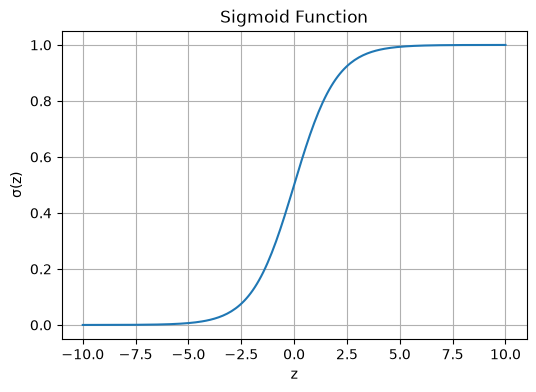

In [64]:
x = np.linspace(-10, 10, 200)
y = sigmoid(x)

plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid(True)
plt.show()

**Binary Cross-Entropy Loss Function Implementation**

To evaluate the quality of the predictions, Binary Cross-Entropy (BCE) was implemented as the loss function.

Unlike Mean Squared Error, BCE is specifically designed for binary classification problems and provides better optimization behavior when combined with the sigmoid activation function.

An epsilon value was used to avoid numerical issues caused by computing the logarithm of zero.

Before training, the model parameters were initialized to zero, producing an initial cost close to 0.693. This value corresponds to a classifier that predicts a probability of 0.5 for every observation.

Parameters:

* X (numpy array): Feature Matrix.
* y (numpy array): True labels.
* w (numpy array): Weights.
* b (float): Bias.

Returns:

* float: The computed binary cross-entropy loss.

In [65]:
def compute_cost(X, y, w, b):

    # Número de ejemplos
    m = X.shape[0]

    # Combinacion lineal
    z = np.dot(X, w) + b

    # Aplicación de la función sigmoide
    y_hat = sigmoid(z)

    # Estabilidad numerica
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    # Cálculo del costo usando la función de pérdida logarítmica
    cost = -np.sum( y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat )) / m
    
    return cost

**Test**

In [66]:
w = np.zeros(X_train.shape[1])
b = 0

initial_cost = compute_cost(
    X_train,
    y_train,
    w,
    b
)

print(initial_cost)

0.6931471805599454


**Gradient Computation**

To optimize the Logistic Regression model, the gradients of the Binary Cross-Entropy loss with respect to the model parameters were implemented manually.

For each iteration, the prediction error is computed as:

$$
\hat{y} - y
$$

The gradients are then calculated as:

- Weights

$$
dw=\frac{1}{m}X^T(\hat y-y)
$$

- Bias

$$
db=\frac{1}{m}\sum(\hat y-y)
$$

These gradients indicate how each parameter should be updated to minimize the loss function during Gradient Descent.

Parameters:

* X (ndarray): Feature matrix.
* y (ndarray): True labels.
* w (ndarray): Model weights.
* b (float): Bias term.

Returns
* dw (ndarray): Gradient with respect to weights.
* db (float): Gradient with respect to bias.

In [67]:
def compute_gradients(X, y, w, b):

    # Número de ejemplos
    m = X.shape[0]

    # Combinacion lineal
    z = np.dot(X, w) + b

    # Aplicación de la función sigmoide
    y_hat = sigmoid(z)

    # Error
    error = y_hat - y

    # Cálculo de los gradientes
    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)

    return dw, db

**Test**

In [68]:
w = np.zeros(X_train.shape[1])
b = 0

dw, db = compute_gradients(X_train, y_train, w, b)

print("Gradient dw:", dw)
print("\nGradient db:", db)
print("\nGradient dw shape:", dw.shape)

Gradient dw: [ 0.12676362  0.09669794  0.06287603 -0.20556055  0.21172901  0.17630173]

Gradient db: -0.013249651324965132

Gradient dw shape: (6,)


**Gradient Descent**

Gradient Descent was implemented to iteratively optimize the Logistic Regression parameters.

The model parameters were initialized to zero and updated according to:

$$
w := w - \alpha dw
$$

$$
b := b - \alpha db
$$

where α represents the learning rate.

The cost value was stored after each iteration to monitor the convergence of the optimization process. As expected, the Binary Cross-Entropy loss decreased progressively during training, indicating that the model successfully learned the relationship between the selected clinical features and the target variable.

In [69]:
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):

    # Número de características
    n = X.shape[1]

    # Inicialización de parámetros
    w = np.zeros(n)
    b = 0

    # Lista para almacenar el costo en cada iteración
    cost_history = []

    for i in range(iterations):
        # Cálculo de gradientes
        dw, db = compute_gradients(X, y, w, b)

        # Actualización de parámetros
        w -= learning_rate * dw
        b -= learning_rate * db

        # Cálculo del costo
        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        # Impresión del costo cada 100 iteraciones
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost}")

    return w, b, cost_history

**Test**

In [70]:
learning_rate = 0.01
iterations = 1000

w, b, cost_history = gradient_descent(
    X_train,
    y_train,
    learning_rate,
    iterations
)

print("Starting Gradient Descent...")
print("Final Cost:", cost_history[-1])

Iteration 0: Cost 0.6916735176619201
Iteration 100: Cost 0.5957862590539205
Iteration 200: Cost 0.5539953445519288
Iteration 300: Cost 0.5327404086492208
Iteration 400: Cost 0.5205281568330034
Iteration 500: Cost 0.5128625874404711
Iteration 600: Cost 0.5077287329996301
Iteration 700: Cost 0.5041195897057451
Iteration 800: Cost 0.5014868195510356
Iteration 900: Cost 0.4995105926082852
Starting Gradient Descent...
Final Cost: 0.4980069287180807


**Visualization**

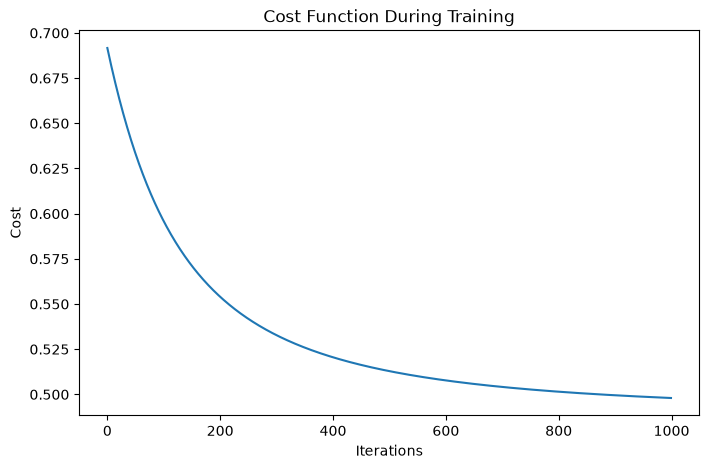

In [71]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.title("Cost Function During Training")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.show()

plt.show()

**Logistic Regression Function**

Due that we are going to use repetly the Logistic Regression training process, a function was implemented to encapsulate the entire training procedure. This function takes the feature matrix, true labels, learning rate, and number of iterations as inputs and returns the optimized model parameters along with the cost history.

Parameters:

* X (ndarray): Training features matrix.
* y (ndarray): Training labels.
* learning_rate (float): Learning rate for gradient descent.
* iterations (int): Number of iterations for gradient descent.

Returns:

* model (dict): Dictionary containing the trained parameters and training history.

In [72]:
def train_logistic_regression(X, y, learning_rate=0.01, iterations=1000):
    w, b, cost_history = gradient_descent(X, y, learning_rate, iterations)

    model = {
        "weights": w,
        "bias": b,
        "cost_history": cost_history,
        "learning_rate": learning_rate,
        "iterations": iterations
    }

    return model

**Evaluation Fuction**

As we did in the training process, a function was implemented to evaluate the model's performance on the test dataset.

Parameters:

* X (ndarray): Features matrix.
* y (ndarray): True labels.
* model (dict): Dictionary containing the trained parameters.

Returns:

* results (dict): Evaluation metrics.

In [73]:
def evaluate_model(X, y, model):
    predictions = predict(X, model["weights"], model["bias"])

    tp, tn, fp, fn = confusion_matrix(y, predictions)

    acc = accuracy(y, predictions)

    prec = precision(tp, fp)

    rec = recall(tp, fn)

    f1 = f1_score(prec, rec)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

### 6. Model Training and Evaluation

Due the nature of the dataset, the dataset as itself dont have probabilities, so we need to trasnform that probabilities into binary values to evaluate the model's performance. A threshold of 0.5 was used, meaning that if the predicted probability is greater than or equal to 0.5, the model predicts the presence of heart disease (1), otherwise it predicts no heart disease (0).

Parameters:

* X (ndarray): Feature matrix.
* w (ndarray): Model weights.
* b (float): Bias term.
* threshold (float): Decision threshold for binary classification.

Returns:

* predictions (ndarray): Binary predictions based on the threshold.

In [74]:
def predict(X, w, b, threshold=0.5):

    z = np.dot(X, w) + b

    probabilities = sigmoid(z)

    predictions = (probabilities >= threshold).astype(int)

    return predictions

**Test**

In [75]:
y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

print("Training Predictions:", y_train_pred[:10])

Training Predictions: [1 0 0 1 1 1 0 1 0 1]


After the predicions, the following metrics were computed to evaluate the model's performance:

* Accuracy
* Precision
* Recall
* F1-Score

Additionally, a confusion matrix was generated to visualize the model's performance in terms of true positives, true negatives, false positives, and false negatives.

**Accuracy Evaluation**

In [76]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

**Confusion Matrix**

Before we implement Precision, Recall and F1-Score, we need to compute the confusion matrix. The confusion matrix is a useful tool for evaluating the performance of a classification model, as it provides a summary of the true positive, true negative, false positive, and false negative predictions.

In [77]:
def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    return tp, tn, fp, fn

**Test**

In [78]:
tp, tn, fp, fn = confusion_matrix(y_test, y_test_pred)

print(tp, tn, fp, fn)

129 105 45 29


**Precision, Recall and F1-Score**

In [79]:
def precision(pt, fp):
    return tp / (tp + fp)

def recall(tp, fn):
    return tp / (tp + fn)

def f1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall)

tp, tn, fp, fn = confusion_matrix(
    y_test,
    y_test_pred
)

acc = accuracy(
    y_test,
    y_test_pred
)

prec = precision(tp, fp)

rec = recall(tp, fn)

f1 = f1_score(prec, rec)

**Visualization**

In [80]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Value": [
        acc,
        prec,
        rec,
        f1
    ]
})

results

,Metric,Value
0,Accuracy,0.759740
1,Precision,0.741379
2,Recall,0.816456
3,F1-Score,0.777108


**Convergence Analysis**

The Binary Cross-Entropy cost decreased steadily during training, indicating that Gradient Descent successfully optimized the Logistic Regression parameters.

The learning rate of **0.01** provided a stable optimization process without oscillations or divergence. Most of the reduction in the cost occurred during the initial iterations, while later iterations produced smaller improvements as the model approached convergence.

In [81]:
coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Weight": w
})

coefficients

,Feature,Weight
0,age,-0.114247
1,trestbps,-0.233713
2,chol,-0.181414
3,thalach,0.604077
4,oldpeak,-0.669580
5,ca,-0.547389


In [82]:
print(df["target"].value_counts())

df.groupby("target")[["oldpeak", "ca", "thalach"]].mean()

target
1    526
0    499
Name: count, dtype: int64


,oldpeak,ca,thalach
target,,,
0,1.600200,1.158317,139.130261
1,0.569962,0.370722,158.585551


**Interpretation of Model Coefficients**

The sign of each coefficient indicates the direction of its contribution with respect to the encoded positive class in the dataset:

- Positive coefficients increase the probability of predicting the positive class.
- Negative coefficients decrease the probability of predicting the positive class.

The magnitude of the coefficient reflects the relative importance of each feature in the linear decision function. Features with larger absolute weights have a greater influence on the model's predictions.

### 7. Decision Boundary

To visualize the decision boundary of Logistic Regression model, three pairs of clinical features were selected following the examples provided:

1. Age vs Cholesterol.
2. Resting Blood Pressures vs Max Heart Rate.
3. ST Depression (Oldpeak) vs Number of Major Vessels.

A separate Logistic Reggression model will be trained for each pair to analyze how well the classes can be separated.

In [83]:
def prepare_feature_pair(df, feature_pair):

    pair_df = df[feature_pair + ["target"]]

    class_0 = pair_df[pair_df["target"] == 0]
    class_1 = pair_df[pair_df["target"] == 1]

    np.random.seed(42)

    class_0 = class_0.sample(frac=1, random_state=42).reset_index(drop=True)
    class_1 = class_1.sample(frac=1, random_state=42).reset_index(drop=True)

    train_size_0 = int(len(class_0) * 0.7)
    train_size_1 = int(len(class_1) * 0.7)

    train_df = pd.concat([
        class_0.iloc[:train_size_0],
        class_1.iloc[:train_size_1]
    ]).sample(frac=1, random_state=42).reset_index(drop=True)

    test_df = pd.concat([
        class_0.iloc[train_size_0:],
        class_1.iloc[train_size_1:]
    ]).sample(frac=1, random_state=42).reset_index(drop=True)

    X_train = train_df[feature_pair]
    y_train = train_df["target"].to_numpy()

    X_test = test_df[feature_pair]
    y_test = test_df["target"].to_numpy()

    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std = np.where(std == 0, 1, std)

    X_train = ((X_train - mean) / std).to_numpy()
    X_test = ((X_test - mean) / std).to_numpy()

    return X_train, X_test, y_train, y_test

**Training the model with selected features**

In [84]:
pair = ["age", "chol"]

X_train_pair, X_test_pair, y_train_pair, y_test_pair = prepare_feature_pair(df, pair)

pair_model = train_logistic_regression(
    X_train_pair,
    y_train_pair,
    learning_rate=0.01,
    iterations=1000
)

pair_results = evaluate_model(
    X_test_pair,
    y_test_pair,
    pair_model
)

pd.DataFrame(pair_results, index=["Age-Cholesterol"])

Iteration 0: Cost 0.6929454964775646
Iteration 100: Cost 0.6777097607611069
Iteration 200: Cost 0.6691285115460613
Iteration 300: Cost 0.6642029743076074
Iteration 400: Cost 0.6613187418223567
Iteration 500: Cost 0.6595985005748831
Iteration 600: Cost 0.6585557557695298
Iteration 700: Cost 0.6579146997717503
Iteration 800: Cost 0.6575156909535144
Iteration 900: Cost 0.6572646056084197


,accuracy,precision,recall,f1_score,TP,TN,FP,FN
Age-Cholesterol,0.613636,0.671875,0.64557,0.65846,102,87,63,56


**Plotting the decision boundary**

In [85]:
def plot_decision_boundary(X, y, model, feature_names):

    # Obtener pesos
    w = model["weights"]
    b = model["bias"]

    # Crear la malla
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1

    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Convertir la malla en una matriz de puntos
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Calcular probabilidades
    z = np.dot(grid, w) + b
    probabilities = sigmoid(z)

    # Convertir nuevamente a la forma de la malla
    probabilities = probabilities.reshape(xx.shape)

    # Dibujar regiones
    plt.figure(figsize=(8,6))

    plt.contourf(
        xx,
        yy,
        probabilities,
        levels=[0, 0.5, 1],
        alpha=0.3
    )

    # Dibujar la frontera
    plt.contour(
        xx,
        yy,
        probabilities,
        levels=[0.5],
        linewidths=2
    )

    # Dibujar pacientes
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        label="No Disease"
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="Disease"
    )

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])

    plt.title(
        f"Decision Boundary: {feature_names[0]} vs {feature_names[1]}"
    )

    plt.legend()

    plt.grid(True)

    plt.show()

**Visualization**

The decision boundary represents the set of points where the Logistic Regression model predicts a probability of 0.5.

To visualize it, a dense grid of points was generated over the feature space. The trained model was used to estimate the probability of the positive class at every point, and the contour corresponding to a probability of 0.5 was drawn as the decision boundary.

This visualization allows us to assess how well two selected features separate patients with and without heart disease.

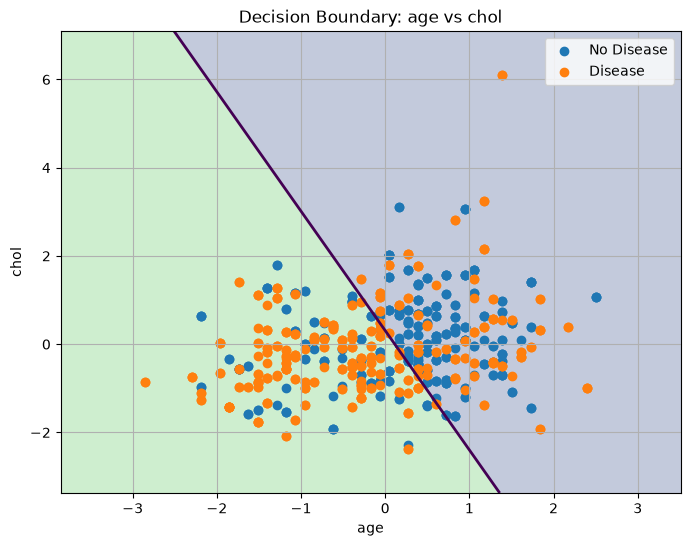

In [86]:
plot_decision_boundary(
    X_train_pair,
    y_train_pair,
    pair_model,
    pair
)

**Conclusion Pair 1: Age vs Cholesterol**

The decision boundary obtained using Age and Cholesterol is linear, as expected from Logistic Regression.

Although the model identifies a separation between the two classes, there is considerable overlap between patients with and without heart disease. This suggests that these two features alone do not provide sufficient discriminatory power.

The visualization indicates that additional clinical variables are required to achieve better classification performance, which justifies the use of multiple features in the complete model.

Iteration 0: Cost 0.6929454964775646
Iteration 100: Cost 0.6777097607611069
Iteration 200: Cost 0.6691285115460613
Iteration 300: Cost 0.6642029743076074
Iteration 400: Cost 0.6613187418223567
Iteration 500: Cost 0.6595985005748831
Iteration 600: Cost 0.6585557557695298
Iteration 700: Cost 0.6579146997717503
Iteration 800: Cost 0.6575156909535144
Iteration 900: Cost 0.6572646056084197


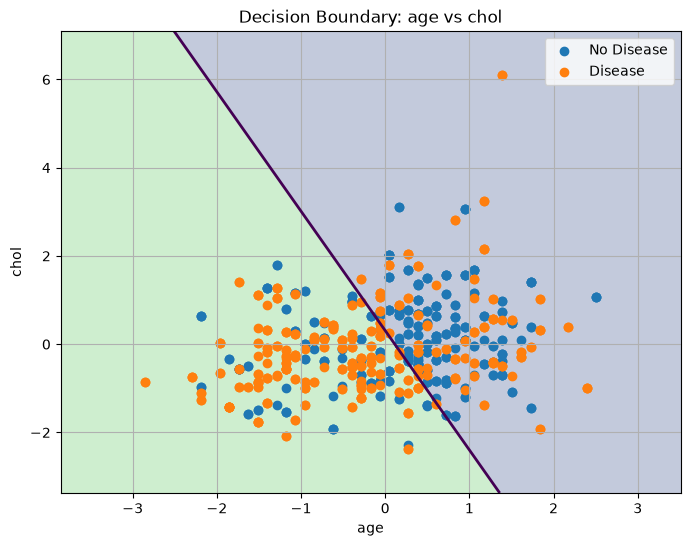

Iteration 0: Cost 0.6926300400079505
Iteration 100: Cost 0.6523468308946909
Iteration 200: Cost 0.6280219323355108
Iteration 300: Cost 0.6129278997976251
Iteration 400: Cost 0.6032812969186946
Iteration 500: Cost 0.5969489705173604
Iteration 600: Cost 0.5926962503875243
Iteration 700: Cost 0.5897851665018574
Iteration 800: Cost 0.5877606163568886
Iteration 900: Cost 0.5863339164623478


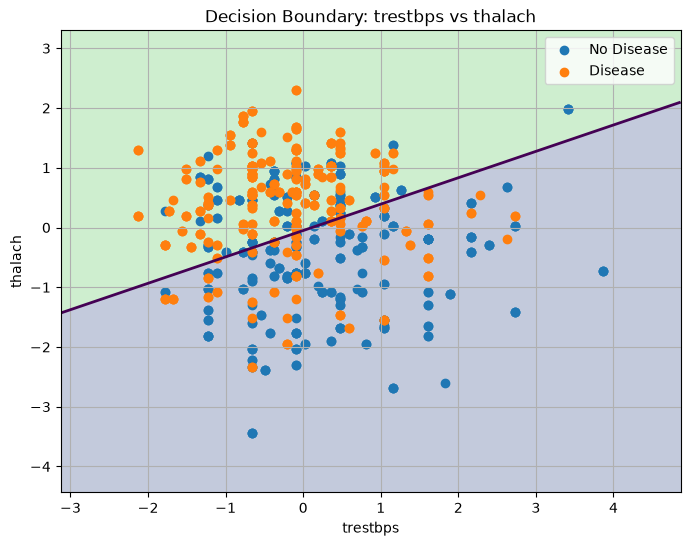

Iteration 0: Cost 0.6923874550669606
Iteration 100: Cost 0.6353235776494511
Iteration 200: Cost 0.6029590215313018
Iteration 300: Cost 0.5835478757852633
Iteration 400: Cost 0.5712988310569524
Iteration 500: Cost 0.5632456589452318
Iteration 600: Cost 0.5577740185963068
Iteration 700: Cost 0.5539556432206366
Iteration 800: Cost 0.5512315938823993
Iteration 900: Cost 0.549252134432464


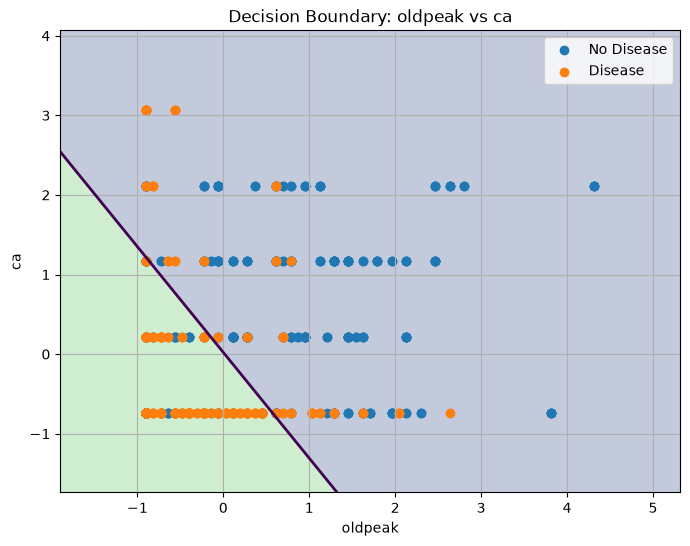

In [87]:
feature_pairs = [
    ["age", "chol"],
    ["trestbps", "thalach"],
    ["oldpeak", "ca"]
]

pair_models = {}
pair_results = {}

for pair in feature_pairs:

    X_train_pair, X_test_pair, y_train_pair, y_test_pair = prepare_feature_pair(df, pair)

    model = train_logistic_regression(
        X_train_pair,
        y_train_pair,
        learning_rate=0.01,
        iterations=1000
    )

    results = evaluate_model(
        X_test_pair,
        y_test_pair,
        model
    )

    pair_name = f"{pair[0]} vs {pair[1]}"

    pair_models[pair_name] = model
    pair_results[pair_name] = results

    plot_decision_boundary(
        X_train_pair,
        y_train_pair,
        model,
        pair
    )

**Conclusion Decision Boundary Analysis**

Three Logistic Regression models were trained using different pairs of clinical features.

The resulting decision boundaries were linear in all cases, reflecting the nature of Logistic Regression.

Some feature pairs exhibited greater overlap between the two classes, indicating limited separability when only two variables were considered. Other pairs produced a clearer separation, suggesting that they carry more predictive information.

### 8. Regularization

To reduce overfitting and improve the generalization capability of the Logistic Regression model, L2 regularization was incorporated into the cost function and the gradient computation.

L2 regularization penalizes large weight values by adding the term

$$
\frac{\lambda}{2m}\|w\|^2
$$

to the Binary Cross-Entropy loss. During optimization, the gradients are also adjusted by adding

$$
\frac{\lambda}{m}w
$$

which encourages smaller model coefficients while leaving the bias term unregularized.

To evaluate the effect of regularization, different values of the regularization parameter λ will be tested and compared in terms of performance and model complexity.

In [88]:
def compute_cost_l2(X, y, w, b, lambda_):

    m = X.shape[0]

    predictions = sigmoid(np.dot(X, w) + b)

    epsilon = 1e-15

    predictions = np.clip(predictions, epsilon, 1 - epsilon)

    bce = -np.mean(
        y * np.log(predictions)
        + (1 - y) * np.log(1 - predictions)
    )

    l2_penalty = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return bce + l2_penalty

In [89]:
def compute_gradients_l2(X, y, w, b, lambda_):
    """
    Compute gradients with L2 regularization.
    """

    m = X.shape[0]

    predictions = sigmoid(np.dot(X, w) + b)

    error = predictions - y

    dw = (1 / m) * np.dot(X.T, error)

    dw += (lambda_ / m) * w

    db = (1 / m) * np.sum(error)

    return dw, db

In [90]:
def gradient_descent_l2(
    X,
    y,
    learning_rate=0.01,
    iterations=1000,
    lambda_=0
):

    n = X.shape[1]

    w = np.zeros(n)

    b = 0

    cost_history = []

    for i in range(iterations):

        dw, db = compute_gradients_l2(
            X,
            y,
            w,
            b,
            lambda_
        )

        w -= learning_rate * dw

        b -= learning_rate * db

        cost = compute_cost_l2(
            X,
            y,
            w,
            b,
            lambda_
        )

        cost_history.append(cost)

    return w, b, cost_history

In [91]:
def train_logistic_regression_l2(
    X,
    y,
    learning_rate=0.01,
    iterations=1000,
    lambda_=0
):

    w, b, cost_history = gradient_descent_l2(
        X,
        y,
        learning_rate,
        iterations,
        lambda_
    )

    return {
        "weights": w,
        "bias": b,
        "cost_history": cost_history,
        "lambda": lambda_
    }

**Trainning with L2 Regularization**

Five values of λ were tested: 0.001, 0.01, 0.1, 1, and 10. The model was trained for each value, and the performance metrics were recorded.

Although predictive performance remained unchanged, increasing λ produced a gradual reduction in the L2 norm of the model weights. This behavior indicates that L2 regularization successfully penalized large coefficients while preserving the model's predictive capability.


In [92]:
lambda_values = [0, 0.001, 0.01, 0.1, 1]

regularized_models = {}
regularized_results = []

for lambda_ in lambda_values:

    model = train_logistic_regression_l2(
        X_train,
        y_train,
        learning_rate=0.01,
        iterations=1000,
        lambda_=lambda_
    )

    metrics = evaluate_model(
        X_test,
        y_test,
        model
    )

    weight_norm = np.linalg.norm(model["weights"])

    regularized_models[lambda_] = model

    regularized_results.append({
        "Lambda": lambda_,
        "Accuracy": metrics["accuracy"],
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1-Score": metrics["f1_score"],
        "Weight Norm": weight_norm
    })

regularization_results = pd.DataFrame(regularized_results)
regularization_results

,Lambda,Accuracy,Precision,Recall,F1-Score,Weight Norm
0,0.000,0.75974,0.741379,0.816456,0.777108,1.101574
1,0.001,0.75974,0.741379,0.816456,0.777108,1.101569
2,0.010,0.75974,0.741379,0.816456,0.777108,1.101518
3,0.100,0.75974,0.741379,0.816456,0.777108,1.101011
4,1.000,0.75974,0.741379,0.816456,0.777108,1.095968


**Cost Function Comparison**

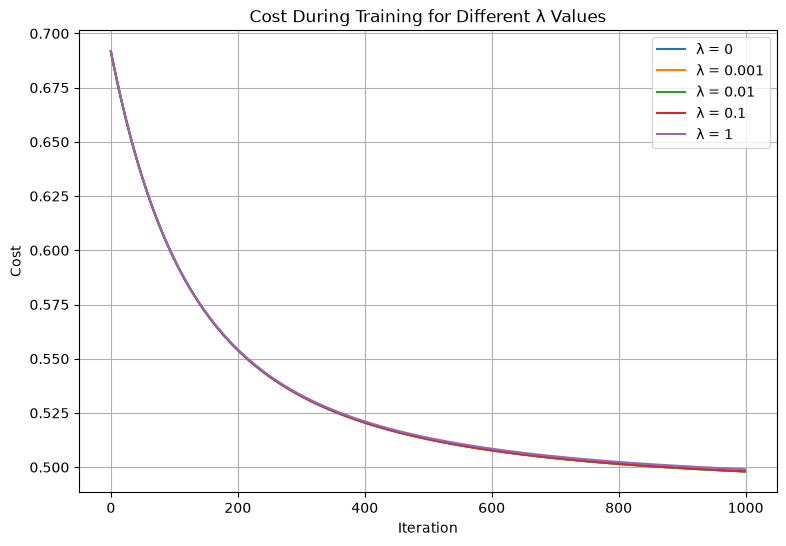

In [93]:
plt.figure(figsize=(9,6))

for lambda_ in lambda_values:

    plt.plot(
        regularized_models[lambda_]["cost_history"],
        label=f"λ = {lambda_}"
    )

plt.title("Cost During Training for Different λ Values")
plt.xlabel("Iteration")
plt.ylabel("Cost")

plt.legend()

plt.grid(True)

plt.show()

**Best λ Selection**

Since all evaluated values of λ produced identical Accuracy, Precision, Recall, and F1-score values, no significant performance differences were observed.

Among the tested values, **λ = 0.1** was selected because it reduced the weight norm more than the smaller values while preserving exactly the same predictive performance.

This choice provides a good balance between model simplicity and classification accuracy.

It's important to note that we would choose **λ = 0.1** due to its good performance metrics and the reduction in the weight norm; however, the problem is that it applies a higher regularization strength.

**Model Training and Comparison with L2 Regularization**

We  will compare the the unregularized Logistic Regression model with the L2 regularized version by training both models on the same dataset and evaluating their performance on the test set. We will use it only for one feature pairs, Age vs Cholesterol, to visualize the effect of regularization on the decision boundary.

In [94]:
# Se preparan los datos para el par de características "age" y "chol"
pair = ["age", "chol"]

X_train_pair, X_test_pair, y_train_pair, y_test_pair = prepare_feature_pair(
    df,
    pair
)

# Entrenamiento del modelo SIN REGULARIZACIÓN
model_no_reg = train_logistic_regression(
    X_train_pair,
    y_train_pair,
    learning_rate=0.01,
    iterations=1000
)

# Entrenamiento del modelo CON REGULARIZACIÓN L2
best_lambda = 0.1  # Mejor valor de λ basado en los resultados anteriores
model_l2 = train_logistic_regression_l2(
    X_train_pair,
    y_train_pair,
    learning_rate=0.01,
    iterations=1000,
    lambda_=best_lambda
)

Iteration 0: Cost 0.6929454964775646
Iteration 100: Cost 0.6777097607611069
Iteration 200: Cost 0.6691285115460613
Iteration 300: Cost 0.6642029743076074
Iteration 400: Cost 0.6613187418223567
Iteration 500: Cost 0.6595985005748831
Iteration 600: Cost 0.6585557557695298
Iteration 700: Cost 0.6579146997717503
Iteration 800: Cost 0.6575156909535144
Iteration 900: Cost 0.6572646056084197


**Visualization**

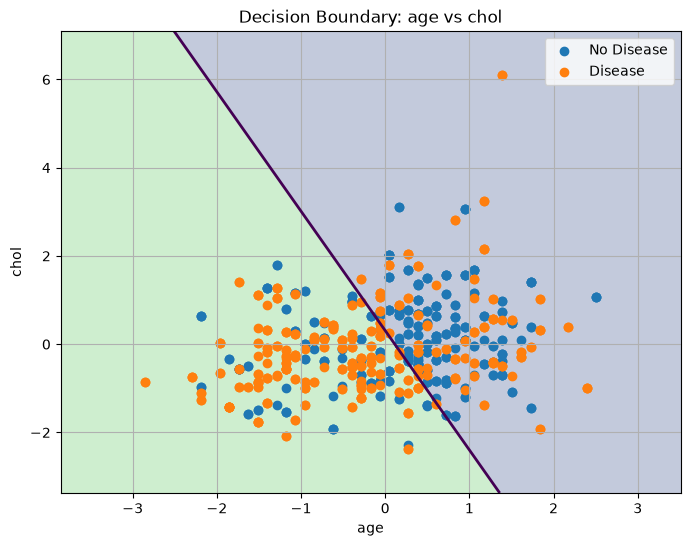

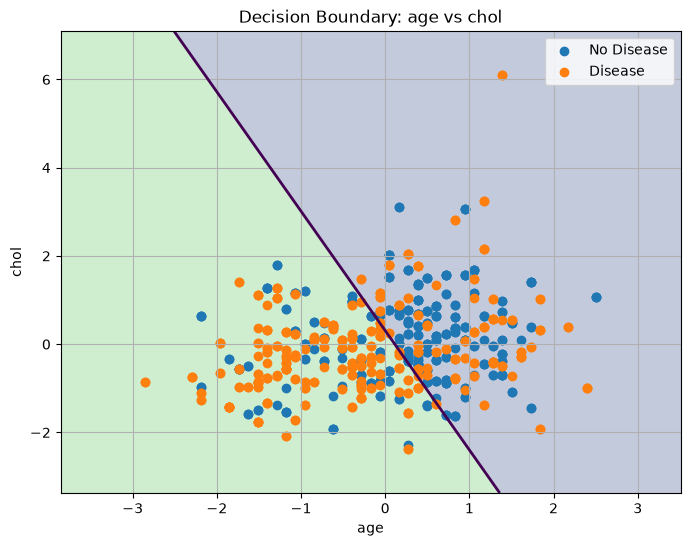

In [95]:
plot_decision_boundary(
    X_train_pair,
    y_train_pair,
    model_no_reg,
    pair
)

plot_decision_boundary(
    X_train_pair,
    y_train_pair,
    model_l2,
    pair
)

**Weights Norm Comparison**


In [96]:
comparison = pd.DataFrame({
    "Model": [
        "Without Regularization",
        "With L2 Regularization"
    ],
    "Weight Norm": [
        np.linalg.norm(model_no_reg["weights"]),
        np.linalg.norm(model_l2["weights"])
    ]
})

comparison

,Model,Weight Norm
0,Without Regularization,0.482949
1,With L2 Regularization,0.482736


**Conclusions**


* The decision boundaries obtained with and without L2 regularization are visually very similar.

* The results of the analysis show that L2 regularization effectively reduces the magnitude of the model's weights without significantly impacting its predictive performance. This suggests that the model is less prone to overfitting and more likely to generalize well to new data.

* The comparison of the two models shows that L2 regularization helps in creating a more robust model that is less sensitive to the specific training data.

* Regularization improved model simplicity without substantially affecting the decision boundary.

* The regularized model produced a smaller weight norm, indicating that the coefficients were slightly shrunk toward zero. Although the reduction is modest, it demonstrates that the L2 penalty was correctly incorporated into the optimization process.

### 9. SageMaker

We are going to use Amazon SageMaker to deploy the Logistic Regression model and make predictions on new patient data. This will allow us to leverage the scalability and reliability of the cloud for our heart disease risk prediction application.

1. Go to the home of the lab in AWS academy.

![](images/home.png)

2. Select the Learner Lab module and start the lab (Click the green button to open the SageMaker Studio environment).

![](images/lab.png)

3. We open the AWS console, we select the domian we created in class.

![](images/console.png)

4. Once in SageMaker Studio, we create a new Code Editor file clicking "Quick Start".

![](images/sagemaker.png)

![](images/quick-start.png)

![](images/code-editor-settings.png)

5. We create a new Code Editor 

### 10. Conclusions